# Exploratory analysis: House transactions

Descriptive statistics on `data/interim/transactions.parquet` (built by `src/load_trades.py`).
Sectors and committee data aren't joined yet, so this covers trade-level structure only:
concentration, time coverage, amounts, tickers, the member-quarter panel, and reporting lag.

Run `python src/load_trades.py` first.

In [74]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"

plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e5e4e0", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.edgecolor": GRAY, "axes.titleweight": "bold", "axes.titlesize": 11,
})
pd.set_option("display.float_format", "{:,.2f}".format)

df = pd.read_parquet(ROOT / "data/interim/transactions.parquet")
df.head()

,memberId,ticker,assetDescription,action,is_sale,partialSale,td,quarter,amountLow,amountHigh,amount_mid,owner,sourceDocId,sourceUrl
0,A000372,ALB,Albemarle Corporation (ALB),purchase,False,False,2021-02-10,2021Q1,"1,001.00","15,000.00","8,000.50",spouse,20018393,https://disclosures-clerk.house.gov/public_dis...
1,A000372,DE,Deere & Company (DE),purchase,False,False,2021-02-10,2021Q1,"15,001.00","50,000.00","32,500.50",not_indicated,20018393,https://disclosures-clerk.house.gov/public_dis...
2,A000372,DE,Deere & Company (DE),purchase,False,False,2021-02-26,2021Q1,"1,001.00","15,000.00","8,000.50",spouse,20018393,https://disclosures-clerk.house.gov/public_dis...
3,A000372,FCX,"Freeport-McMoRan, Inc. (FCX)",purchase,False,False,2021-02-26,2021Q1,"1,001.00","15,000.00","8,000.50",spouse,20018393,https://disclosures-clerk.house.gov/public_dis...
4,A000372,FCX,"Freeport-McMoRan, Inc. (FCX)",purchase,False,False,2021-02-10,2021Q1,"15,001.00","50,000.00","32,500.50",not_indicated,20018393,https://disclosures-clerk.house.gov/public_dis...


## 1. Overview

In [75]:
pd.Series({
    "trades": len(df),
    "members": df.memberId.nunique(),
    "tickers": df.ticker.nunique(),
    "filings": df.sourceDocId.nunique(),
    "quarters": df.quarter.nunique(),
    "first trade": df.td.min().date(),
    "last trade": df.td.max().date(),
})

trades              58162
members               201
tickers              2643
filings              2233
quarters               23
first trade    2021-01-04
last trade     2026-09-22
dtype: object

In [76]:
nulls = df.isna().sum()
nulls[nulls > 0]

amountLow     193
amountHigh    213
amount_mid    213
dtype: int64

## 2. Concentration across members

In [77]:
per_member = df.memberId.value_counts()
per_member.describe(percentiles=[.25, .5, .75, .9, .99])

count      201.00
mean       289.36
std      1,863.08
min          1.00
25%          4.00
50%         20.00
75%        136.00
90%        333.00
99%      2,611.00
max     25,414.00
Name: count, dtype: float64

In [78]:
# The interim table has no names; memberId -> displayName is 1:1 in the raw data.
names = (
    pd.concat([pd.read_parquet(ROOT / f"data/raw/{y}-00000-of-00001.parquet", columns=["memberId", "displayName"])
               for y in range(2021, 2027)])
    .drop_duplicates("memberId").set_index("memberId").displayName
)

top = per_member.head(10).to_frame("trades")
top.insert(0, "name", names.reindex(top.index))
top["share"] = top.trades / len(df)
top["cum share"] = top.share.cumsum()
top

,name,trades,share,cum share
memberId,,,,
K000389,Ro Khanna,25414,0.44,0.44
M001157,Michael T. McCaul,6397,0.11,0.55
H001086,Diana Harshbarger,2611,0.04,0.59
G000583,Josh Gottheimer,2472,0.04,0.63
C001123,"Gilbert Ray Cisneros, Jr.",1532,0.03,0.66
M001136,Lisa C. McClain,1420,0.02,0.69
G000599,Daniel S. Goldman,1194,0.02,0.71
M001135,Kathy E. Manning,741,0.01,0.72
H001082,Kevin Hern,669,0.01,0.73


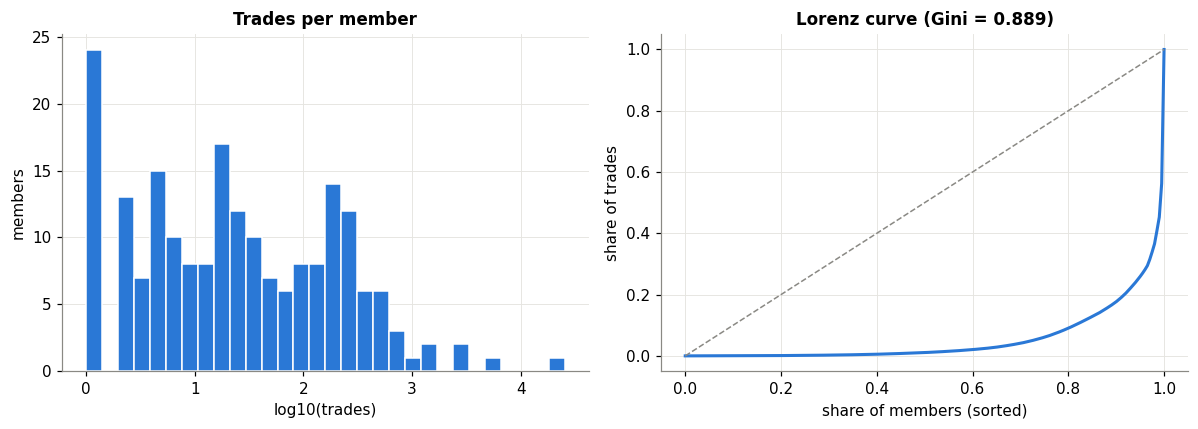

In [79]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    return (2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum())

x = np.sort(per_member.values)
lorenz = np.insert(x.cumsum() / x.sum(), 0, 0)
members_frac = np.linspace(0, 1, len(lorenz))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.hist(np.log10(per_member), bins=30, color=BLUE, edgecolor="white", linewidth=1)
a1.set(title="Trades per member", xlabel="log10(trades)", ylabel="members")
a2.plot(members_frac, lorenz, color=BLUE, lw=2)
a2.plot([0, 1], [0, 1], color=GRAY, lw=1, ls="--")
a2.set(title=f"Lorenz curve (Gini = {gini(per_member):.3f})",
       xlabel="share of members (sorted)", ylabel="share of trades")
plt.tight_layout()

Two members hold over half the rows. Any row-weighted statistic or loss will mostly describe them,
which is why the pipeline caps or weights per member. The median member is the more representative unit.

## 3. Coverage over time

In [80]:
by_q = df.groupby("quarter").agg(
    trades=("ticker", "size"),
    members=("memberId", "nunique"),
    tickers=("ticker", "nunique"),
)
by_q["trades excl. top 2"] = df[~df.memberId.isin(per_member.index[:2])].groupby("quarter").size()
by_q

,trades,members,tickers,trades excl. top 2
quarter,,,,
2021Q1,2639,73,751,2286
2021Q2,2079,65,621,1536
2021Q3,3211,62,785,1266
2021Q4,2758,69,741,950
2022Q1,3427,67,801,1402
2022Q2,3929,57,818,981
2022Q3,2626,56,637,1127
2022Q4,2457,54,721,896
2023Q1,2424,56,769,1285


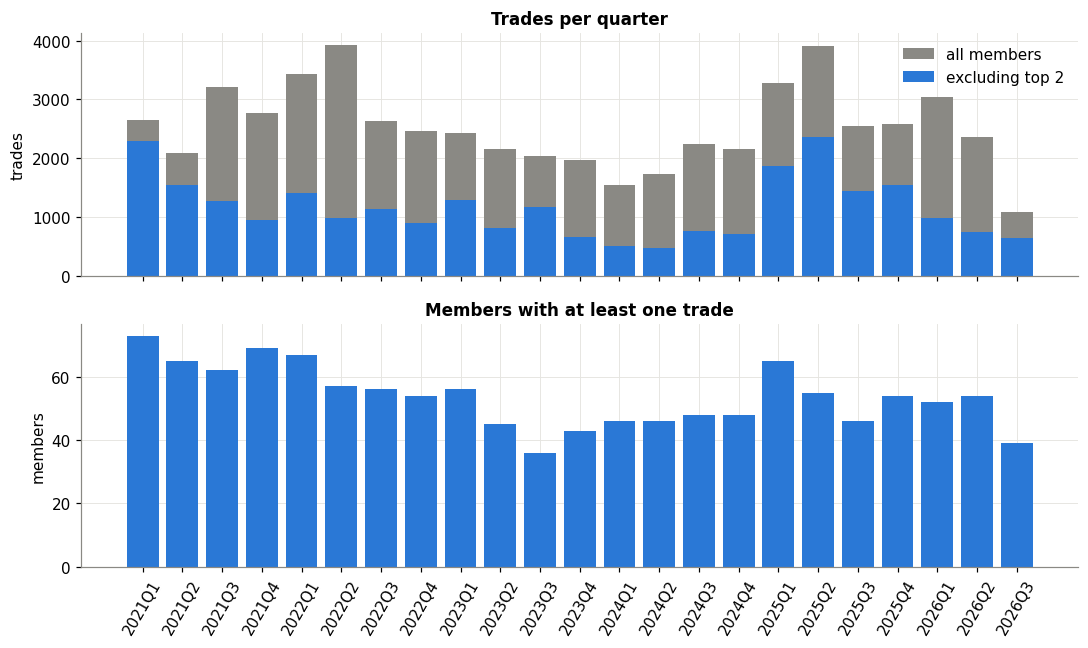

In [81]:
qlabels = by_q.index.astype(str)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].bar(qlabels, by_q.trades, color=GRAY, label="all members")
axes[0].bar(qlabels, by_q["trades excl. top 2"], color=BLUE, label="excluding top 2")
axes[0].set(title="Trades per quarter", ylabel="trades")
axes[0].legend(frameon=False)
axes[1].bar(qlabels, by_q.members, color=BLUE)
axes[1].set(title="Members with at least one trade", ylabel="members")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()

The last quarter or two are right-censored: trades there may not be disclosed yet (see section 8).
Treat the most recent quarters as incomplete when choosing a test split.

## 4. Action and owner

In [82]:
pd.crosstab(df.action, df.partialSale, margins=True)

partialSale,False,True,All
action,,,
exchange,144,0,144
purchase,28782,124,28906
sale,20450,8660,29110
unmarked,2,0,2
All,49378,8784,58162


`partialSale` is almost entirely on sales, but ~120 purchases carry it too, likely extraction noise.
`exchange` and `unmarked` are rare enough to drop or fold into another class.

In [83]:
owner = pd.crosstab(df.owner, df.action, normalize="index")[["purchase", "sale"]]
owner["trades"] = df.owner.value_counts()
owner.sort_values("trades", ascending=False)

action,purchase,sale,trades
owner,,,
spouse,0.51,0.49,22824
dependent_child,0.51,0.49,15387
not_indicated,0.49,0.50,13028
joint,0.44,0.56,6919
self,0.25,0.75,4


## 5. Amounts

Disclosures give amount *ranges*, not values. Most rows sit in the standard STOCK Act brackets;
a few filers report exact amounts (`amountLow == amountHigh`), and open-ended top brackets have no `amountHigh`.

In [84]:
lo, hi = df.amountLow, df.amountHigh
kind = np.select(
    [lo.isna(), hi.isna(), lo == hi],
    ["missing", "open-ended", "exact"],
    default="bracket",
)
pd.Series(kind).value_counts()

bracket       57879
missing         193
exact            70
open-ended       20
Name: count, dtype: int64

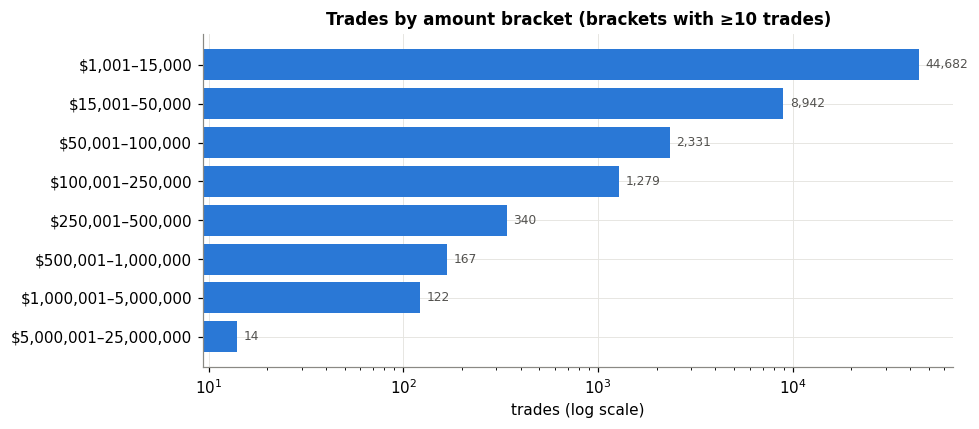

In [85]:
brackets = (
    df.loc[kind == "bracket"]
    .groupby(["amountLow", "amountHigh"]).size().rename("trades")
    .reset_index()
)
brackets["label"] = [f"${l:,.0f}–{h:,.0f}" for l, h in zip(brackets.amountLow, brackets.amountHigh)]
brackets = brackets[brackets.trades >= 10]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(brackets.label, brackets.trades, color=BLUE)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set(title="Trades by amount bracket (brackets with ≥10 trades)", xlabel="trades (log scale)")
for y, v in enumerate(brackets.trades):
    ax.text(v * 1.08, y, f"{v:,}", va="center", fontsize=8, color="#52514e")
plt.tight_layout()

In [86]:
# Midpoint is a crude value estimate; the top bracket is a lower bound.
vol = df.groupby("memberId").amount_mid.sum().sort_values(ascending=False)
pd.DataFrame({
    "name": names.reindex(per_member.head(10).index),
    "trade share": per_member.head(10) / len(df),
    "est. dollar share": (vol / vol.sum()).reindex(per_member.head(10).index),
})

,name,trade share,est. dollar share
memberId,,,
K000389,Ro Khanna,0.44,0.17
M001157,Michael T. McCaul,0.11,0.19
H001086,Diana Harshbarger,0.04,0.01
G000583,Josh Gottheimer,0.04,0.17
C001123,"Gilbert Ray Cisneros, Jr.",0.03,0.01
M001136,Lisa C. McClain,0.02,0.01
G000599,Daniel S. Goldman,0.02,0.02
M001135,Kathy E. Manning,0.01,0.00
H001082,Kevin Hern,0.01,0.02


Row count and estimated dollar volume rank members differently (e.g. Ro Khanna is 44% of rows
but ~17% of dollars). Which one to weight toward is a design choice.

## 6. Tickers

In [87]:
per_ticker = df.ticker.value_counts()
pd.Series({
    "tickers": len(per_ticker),
    "traded once": (per_ticker == 1).mean(),
    "traded ≤ 5 times": (per_ticker <= 5).mean(),
    "trades in top 50 tickers": per_ticker.head(50).sum() / len(df),
})

tickers                    2,643.00
traded once                    0.24
traded ≤ 5 times               0.55
trades in top 50 tickers       0.23
dtype: float64

ticker,AAPL,MSFT,AMZN,NVDA,GOOGL,JPM,PG,UNH,T,JNJ,V,MRK,DIS,VZ,BRK-B,PEP,AVGO,GOOG,META,NEE
trades,472,766,543,489,419,245,274,332,226,272,325,271,300,220,147,210,246,291,326,138
members,71,68,61,51,49,48,45,43,43,42,41,40,39,38,38,36,35,35,35,34


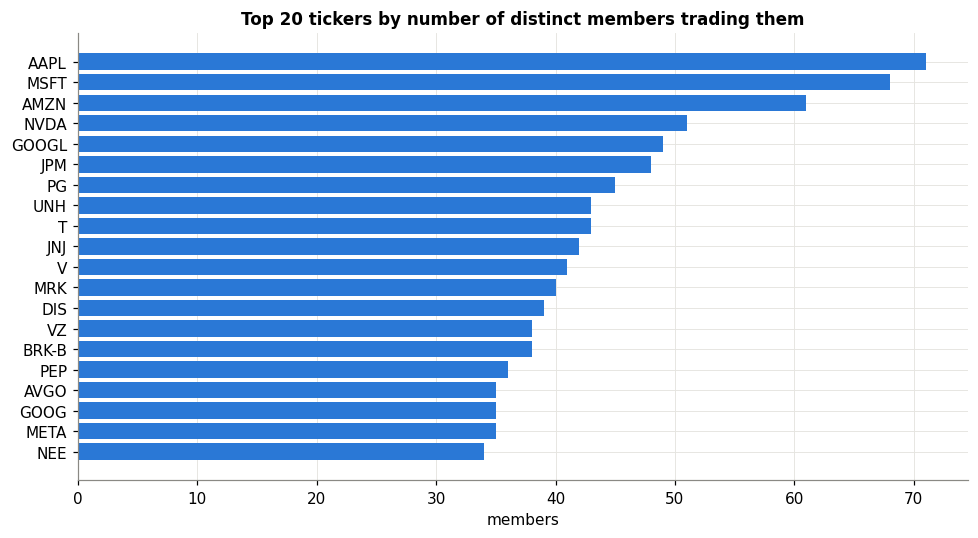

In [88]:
# Members per ticker is less distorted by heavy traders than raw row count.
t20 = (
    df.groupby("ticker")
    .agg(trades=("memberId", "size"), members=("memberId", "nunique"))
    .sort_values("members", ascending=False)
    .head(20)
)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(t20.index, t20.members, color=BLUE)
ax.invert_yaxis()
ax.set(title="Top 20 tickers by number of distinct members trading them", xlabel="members")
plt.tight_layout()
t20.T

In [89]:
tickers_per_member = df.groupby("memberId").ticker.nunique()
tickers_per_member.describe(percentiles=[.25, .5, .75, .9])

count   201.00
mean     48.37
std     106.75
min       1.00
25%       2.00
50%      11.00
75%      44.00
90%     113.00
max     917.00
Name: ticker, dtype: float64

## 7. Member-quarter panel

The modeling unit is one row per member-quarter. These stats show how sparse the panel is and
how predictable a member's next quarter is from the last, before any sector mapping.

In [90]:
mq = df.groupby(["memberId", "quarter"]).agg(
    trades=("ticker", "size"),
    tickers=("ticker", "nunique"),
    sale_share=("is_sale", "mean"),
)
n_members, n_quarters = df.memberId.nunique(), df.quarter.nunique()
pd.Series({
    "active member-quarters": len(mq),
    "full panel (members × quarters)": n_members * n_quarters,
    "fill rate": len(mq) / (n_members * n_quarters),
    "median active quarters per member": mq.groupby("memberId").size().median(),
})

active member-quarters              1,236.00
full panel (members × quarters)     4,623.00
fill rate                               0.27
median active quarters per member       4.00
dtype: float64

In [91]:
mq[["trades", "tickers", "sale_share"]].describe(percentiles=[.25, .5, .75, .9])

,trades,tickers,sale_share
count,"1,236.00","1,236.00","1,236.00"
mean,47.06,21.74,0.52
std,174.63,60.04,0.37
min,1.00,1.00,0.00
25%,2.00,1.00,0.20
50%,6.00,4.00,0.50
75%,21.00,14.00,0.98
90%,81.00,48.00,1.00
max,"2,612.00",572.00,1.00


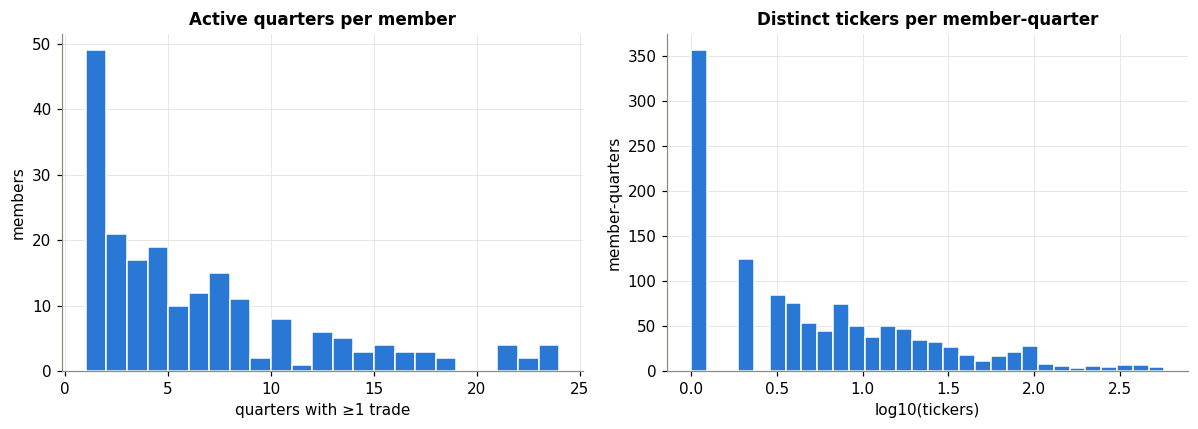

In [92]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.hist(mq.groupby("memberId").size(), bins=range(1, n_quarters + 2), color=BLUE, edgecolor="white")
a1.set(title="Active quarters per member", xlabel="quarters with ≥1 trade", ylabel="members")
a2.hist(np.log10(mq.tickers), bins=30, color=BLUE, edgecolor="white")
a2.set(title="Distinct tickers per member-quarter", xlabel="log10(tickers)", ylabel="member-quarters")
plt.tight_layout()

In [93]:
# Persistence: is an active member active next quarter, and how much do their tickers overlap?
sets = df.groupby(["memberId", "quarter"]).ticker.agg(set)
rows = []
for (m, q), s in sets.items():
    nxt = sets.get((m, q + 1))
    rows.append({
        "memberId": m, "quarter": q,
        "active_next": nxt is not None,
        "jaccard_next": len(s & nxt) / len(s | nxt) if nxt is not None else np.nan,
    })
persist = pd.DataFrame(rows)
persist = persist[persist.quarter < df.quarter.max()]
pd.Series({
    "P(active next | active now)": persist.active_next.mean(),
    "median ticker Jaccard, consecutive quarters": persist.jaccard_next.median(),
    "mean ticker Jaccard, consecutive quarters": persist.jaccard_next.mean(),
})

P(active next | active now)                   0.67
median ticker Jaccard, consecutive quarters   0.18
mean ticker Jaccard, consecutive quarters     0.29
dtype: float64

High persistence supports the "historical mix" baseline in the README. Ticker overlap is a lower
bound on sector overlap, since different tickers often share a sector.

## 8. Reporting lag

The interim table drops `availableAt`, so this re-reads the raw files with the same filters.
Lag = `availableAt − transactionDate`. The STOCK Act deadline is 45 days.

In [94]:
raw = pd.concat(
    [pd.read_parquet(ROOT / f"data/raw/{y}-00000-of-00001.parquet") for y in range(2021, 2027)],
    ignore_index=True,
)
raw["td"] = pd.to_datetime(raw.transactionDate, errors="coerce")
raw = raw[raw.supersededAt.isna() & (raw.chamber == "house") & raw.ticker.notna()
          & raw.td.between("2021-01-01", "2026-09-30")]
assert len(raw) == len(df)

lag = (raw.availableAt - raw.td).dt.days
lag.describe(percentiles=[.1, .25, .5, .75, .9, .99])

count   58,162.00
mean        40.86
std         82.14
min          1.00
10%         12.00
25%         19.00
50%         28.00
75%         35.00
90%         44.00
99%        415.00
max      1,404.00
dtype: float64

In [95]:
late = lag > 45
pd.Series({
    "share filed after 45 days": late.mean(),
    "share filed after 45 days (members, equal weight)": late.groupby(raw.memberId).mean().mean(),
    "negative lag (data error)": (lag < 0).sum(),
})

share filed after 45 days                           0.09
share filed after 45 days (members, equal weight)   0.20
negative lag (data error)                           0.00
dtype: float64

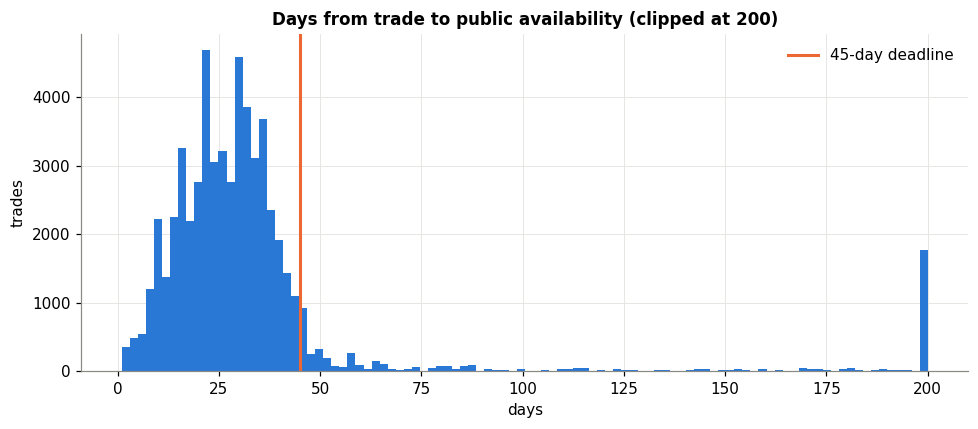

In [96]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lag.clip(0, 200), bins=100, color=BLUE)
ax.axvline(45, color=ORANGE, lw=2, label="45-day deadline")
ax.set(title="Days from trade to public availability (clipped at 200)",
       xlabel="days", ylabel="trades")
ax.legend(frameon=False)
plt.tight_layout()

Because disclosure lags the trade, a feature built from "trades in quarter *q*" isn't fully known at the
end of *q*. Features must be filtered on `availableAt`, as the README specifies, and `availableAt` should
probably be carried into the interim table.

## 9. Data quality

In [97]:
dup_cols = ["memberId", "ticker", "td", "action", "amountLow", "owner"]
dups = df[df.duplicated(dup_cols, keep=False)]
pd.Series({
    "rows sharing member/ticker/date/action/amount/owner": len(dups),
    "share of all rows": len(dups) / len(df),
    "members involved": dups.memberId.nunique(),
    "top member's share of these": dups.memberId.value_counts(normalize=True).iloc[0],
})

rows sharing member/ticker/date/action/amount/owner   5,166.00
share of all rows                                         0.09
members involved                                         71.00
top member's share of these                               0.45
dtype: float64

These can be legitimate (several lots on one day) or double extraction. Since labels are the *set*
of sectors per quarter, they don't change labels, only count features.

## Takeaways

- Two members are over half the data; weight or cap per member, and report member-level (not row-level) stats.
- The member-quarter panel is sparse but persistent, so the historical-mix baseline will be strong.
- Most recent quarters are incomplete because of reporting lag; use `availableAt` for features and be careful
  with the last quarters in the test split.
- Amounts are brackets; count-based and dollar-based views of activity disagree.
- Minor cleanup: `partialSale` on purchases, rare `exchange`/`unmarked` actions, possible duplicate rows.